In [87]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohanharode07/webmd-drug-reviews-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/hungnguyen/.cache/kagglehub/datasets/rohanharode07/webmd-drug-reviews-dataset/versions/1


In [88]:
# List the head of dataset files
import os
print("Files in dataset directory:", os.listdir(path))
# Load the dataset using pandas
import pandas as pd
dataset_file = os.path.join(path, "webmd.csv")
df = pd.read_csv(dataset_file)
df.head()

Files in dataset directory: ['webmd.csv']


,Age,Condition,Date,Drug,DrugId,EaseofUse,Effectiveness,Reviews,Satisfaction,Sex,Sides,UsefulCount
0,75 or over,Stuffy Nose,9/21/2014,25dph-7.5peh,146724,5,5,I'm a retired physician and of all the meds I ...,5,Male,"Drowsiness, dizziness , dry mouth /nose/thro...",0
1,25-34,Cold Symptoms,1/13/2011,25dph-7.5peh,146724,5,5,cleared me right up even with my throat hurtin...,5,Female,"Drowsiness, dizziness , dry mouth /nose/thro...",1
2,65-74,Other,7/16/2012,warfarin (bulk) 100 % powder,144731,2,3,why did my PTINR go from a normal of 2.5 to ov...,3,Female,,0
3,75 or over,Other,9/23/2010,warfarin (bulk) 100 % powder,144731,2,2,FALLING AND DON'T REALISE IT,1,Female,,0
4,35-44,Other,1/6/2009,warfarin (bulk) 100 % powder,144731,1,1,My grandfather was prescribed this medication ...,1,Male,,1


In [89]:
# get 1000 rows from df 
df = df.sample(1000)
# print to the new file called webmd_1000.csv
# df.to_csv("webmd_1000.csv", index=False)


# df = df[["Age", "Condition", "Drug", "DrugId", "Satisfaction", "Sex", "Reviews"]]

df.isnull().sum()

Age              0
Condition        0
Date             0
Drug             0
DrugId           0
EaseofUse        0
Effectiveness    0
Reviews          0
Satisfaction     0
Sex              0
Sides            0
UsefulCount      0
dtype: int64

In [90]:
df = df.dropna()

for col in df.columns:
    if df[col].dtype.kind == "O":
        df[col] = df[col].str.strip()

df["Reviews"] = df["Reviews"].astype(str).str.strip()


def satisfaction_to_class(rating: int) -> int:
    """Map WebMD 1–5 satisfaction to 0=Negative, 1=Neutral, 2=Positive."""
    r = int(rating)
    if r <= 2:
        return 0
    if r >= 2 and r <= 3:
        return 1
    if r >= 4 and r <= 5:
        return 2
    return -1

def filter_anomalies(df: pd.DataFrame, min_review_len: int = 10) -> pd.DataFrame:
    """Remove nulls and very short/uninformative reviews."""
    before = len(df)
    df = df.dropna(subset=["Reviews"]).copy()
    df = df[df["Reviews"].str.strip().str.len() >= min_review_len].copy()
    print(f"\n[3] Anomaly filter: removed {before - len(df)} rows "
          f"(null or < {min_review_len} chars).  Remaining: {len(df):,}")
    return df

def filter_anomalies_report(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)
    df_filtered = filter_anomalies(df)
    after = len(df_filtered)

    removed = before - after
    removed_pct = (removed / before) * 100 if before > 0 else 0

    print("\n[3] Anomaly Filter Summary")
    print(f"-----------------------------------")
    print(f"Rows before filtering : {before:,}")
    print(f"Rows after filtering  : {after:,}")
    print(f"Rows removed          : {removed:,}")
    print(f"Percent removed       : {removed_pct:.2f}%")
    return df_filtered

df = filter_anomalies_report(df)
len(df)


[3] Anomaly filter: removed 112 rows (null or < 10 chars).  Remaining: 888

[3] Anomaly Filter Summary
-----------------------------------
Rows before filtering : 1,000
Rows after filtering  : 888
Rows removed          : 112
Percent removed       : 11.20%


888

filter_anomalies_report(df)

In [91]:
from transformers import pipeline
from tqdm import tqdm
import torch

#list of models used in the paper
models = {
    "roberta-twitter": "cardiffnlp/twitter-roberta-base-sentiment",
    "distilbert-sst2": "distilbert-base-uncased-finetuned-sst-2-english",
    "bio-bert": "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract"
}

# Check if MPS is available
device = 0 if torch.backends.mps.is_available() else -1
print("Using device:", "MPS GPU" if device == 0 else "CPU")

# classifier = pipeline(
#     "sentiment-analysis",
#     model="cardiffnlp/twitter-roberta-base-sentiment",
#     device=6 # GPU
# )

pipelines = {}

for name, model_name in models.items():
    pipelines[name] = pipeline(
        "sentiment-analysis",
        model=model_name,
        device=0, # change to 0 if using GPU
        truncation=True,
        padding=True,
        max_length=512  
    )
    
texts = df["Reviews"].tolist()

results = []
batch_size = 32

# for i in tqdm(range(0, len(texts), batch_size)):
#     batch = texts[i:i+batch_size]
#     outputs = classifier(batch, batch_size=batch_size)
#     results.extend(outputs)

import time

for model_name, clf in pipelines.items():
    print(f"Running {model_name}...")
    start_time = time.time()
    
    labels = []
    scores = []
    
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        outputs = clf(batch)
        
        for output in outputs:
            labels.append(output["label"])
            scores.append(output["score"])
    
    # Assign results back to dataframe
    df[f"{model_name}_label"] = labels
    df[f"{model_name}_score"] = scores

    print(f"{model_name} finished in {time.time() - start_time:.2f}s")

df["roberta-twitter_label_transformed"] = df["roberta-twitter_label"].map({"LABEL_0": 0, "LABEL_1": 1, "LABEL_2": 2})
df["distilbert-sst2_label_transformed"] = df["distilbert-sst2_label"].map({"POSITIVE": 2, "NEGATIVE": 0})
df["bio-bert_label_transformed"] = df["bio-bert_label"].map({"LABEL_0": 0, "LABEL_1": 2})


# save the df to a csv file
df.to_csv("3_models_results_transformed-test.csv", index=False)
df.head()



Using device: MPS GPU


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 31960.54it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 35528.31it/s]
BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight           

Running roberta-twitter...


100%|██████████| 28/28 [00:36<00:00,  1.30s/it]


roberta-twitter finished in 36.45s
Running distilbert-sst2...


100%|██████████| 28/28 [00:19<00:00,  1.45it/s]


distilbert-sst2 finished in 19.26s
Running bio-bert...


100%|██████████| 28/28 [00:29<00:00,  1.06s/it]

bio-bert finished in 29.59s


,Age,Condition,Date,Drug,DrugId,EaseofUse,Effectiveness,Reviews,Satisfaction,Sex,...,UsefulCount,roberta-twitter_label,roberta-twitter_score,distilbert-sst2_label,distilbert-sst2_score,bio-bert_label,bio-bert_score,roberta-twitter_label_transformed,distilbert-sst2_label_transformed,bio-bert_label_transformed
120915,45-54,Disease in which Body has Immune Response Agai...,3/26/2008,prednisone,6007,4,5,"In 1998, I was diagnosed with Hep C and an aut...",1,Female,...,27,LABEL_0,0.734079,NEGATIVE,0.998587,LABEL_1,0.552812,0,0,2
23242,35-44,Visible Water Retention,6/27/2010,lasix,3776,5,2,this med no were in its pamplets that you get ...,1,Female,...,8,LABEL_0,0.715879,NEGATIVE,0.998666,LABEL_1,0.548018,0,0,2
143204,35-44,Other,8/26/2012,requip,4638,3,3,I have been on 1mg of Requip for many years fo...,1,Female,...,2,LABEL_0,0.395357,NEGATIVE,0.998408,LABEL_0,0.591499,0,0,0
275227,19-24,Inflammation of the Eye,6/21/2010,"fluorometholone suspension, drops (final dose ...",12354,2,4,My eye doctor instructed me to take FML 4 time...,2,Female,...,38,LABEL_0,0.871253,NEGATIVE,0.994997,LABEL_0,0.510626,0,0,0
31495,35-44,Enlarged Thyroid Gland,7/16/2009,levothyroxine solution,1433,3,2,i have yet to see a difference with taking thi...,1,Female,...,1,LABEL_0,0.716747,NEGATIVE,0.999483,LABEL_0,0.504620,0,0,0


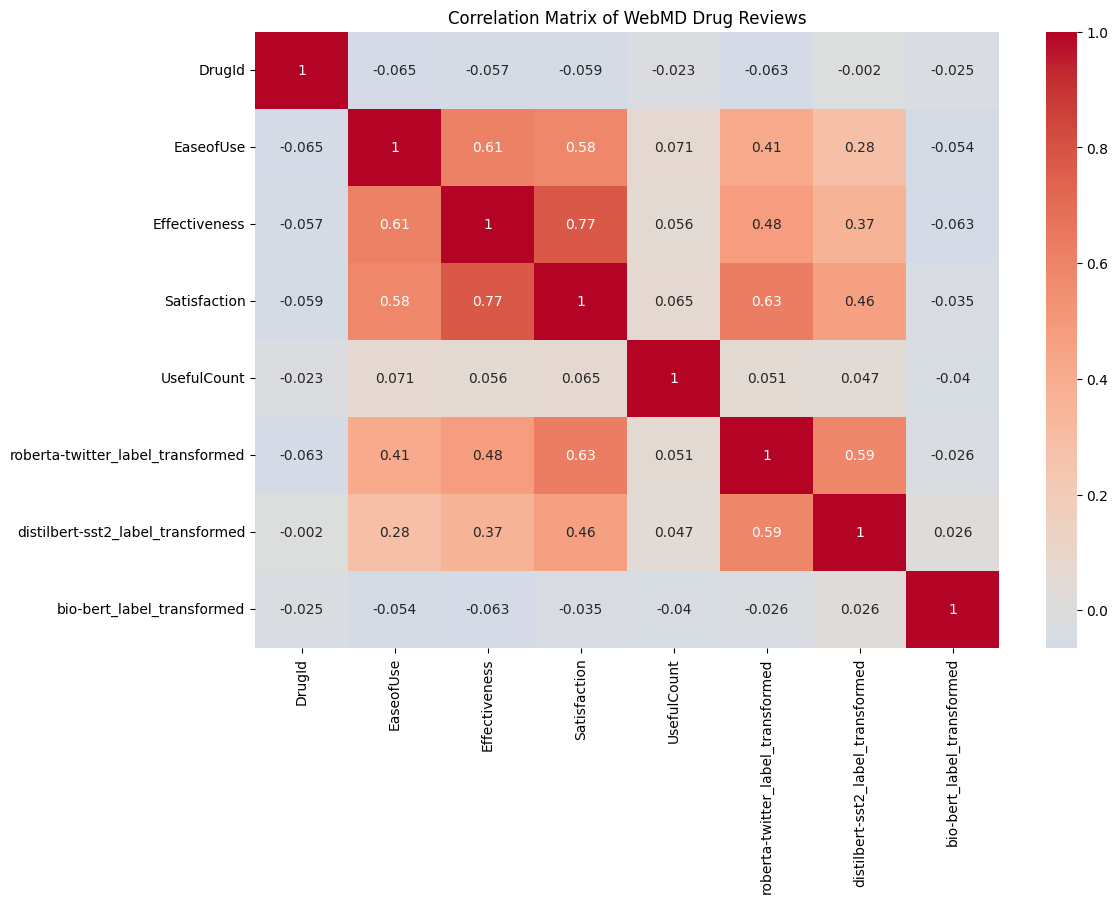

In [92]:
# draw the correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix (numeric columns only; Age is e.g. "19-24", not numeric)
df_no_score = df.drop(columns=["roberta-twitter_score", "distilbert-sst2_score", "bio-bert_score"])
correlation_matrix = df_no_score.select_dtypes(include="number").corr()

# Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of WebMD Drug Reviews")
plt.show()

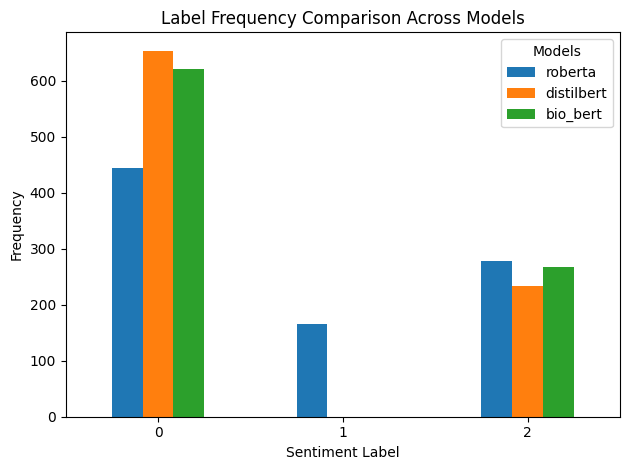

In [93]:
# Count labels for each model
roberta_counts = df["roberta-twitter_label_transformed"].value_counts()
distilbert_counts = df["distilbert-sst2_label_transformed"].value_counts()
bio_bert_counts = df["bio-bert_label_transformed"].value_counts()

# Combine into one DataFrame
label_counts = pd.DataFrame({
    "roberta": roberta_counts,
    "distilbert": distilbert_counts,
    "bio_bert": bio_bert_counts
}).fillna(0)

label_counts.plot(kind="bar")

plt.title("Label Frequency Comparison Across Models")
plt.xlabel("Sentiment Label")
plt.ylabel("Frequency")
plt.xticks(rotation=0)

plt.legend(title="Models")
plt.tight_layout()
plt.show()

In [94]:
# compare model labels with satisfaction-derived labels

df["label_satisfaction"] = df["Satisfaction"].apply(satisfaction_to_class)

# compare like-for-like strings
df["is_same"] = df["label_satisfaction"] == df["roberta_results"]

# plot percentages using dynamic labels to avoid label-length mismatch
counts = df["is_same"].value_counts()
plt.figure(figsize=(10, 6))
plt.pie(counts.values, labels=counts.index.astype(str), autopct="%1.1f%%")
plt.title("Percentage of Matched vs Unmatched Satisfaction Ratings and Roberta Labels")
plt.show()



KeyError: 'roberta_results'